In [1]:
# 1. Load data
# ===============================
# Import necessary libraries
import pandas as pd   # For data manipulation
import numpy as np    # For numerical operations
import matplotlib.pyplot as plt  # For plotting

In [2]:
# Load the dataset
df = pd.read_csv("C:/Users/User/OneDrive - Singapore Polytechnic/Desktop/AI ML/CA1-Dataset/CA1-Dataset/factory_data.csv")
# Read CSV file into a DataFrame

In [3]:
# Explore the DataFrame
shape_of_df=df.shape
print(f'Shape: {shape_of_df}')

index_of_df=df.index
print(f'Index: {index_of_df}')

column_of_df=df.columns
print(f'Columns: {column_of_df}')

print('DataFrame info:')
df.info()

describe_of_df=df.describe()
print(f'Descriptive Statistics: {describe_of_df}')

head_of_df = df.head()
print(f'First 5 rows:\n{head_of_df}')

# Check for missing values
missing_of_df = df.isnull().sum()
print(f'Missing values per column:\n{missing_of_df}')

Shape: (20000, 9)
Index: RangeIndex(start=0, stop=20000, step=1)
Columns: Index(['Unique ID', 'Product ID', 'Quality', 'Ambient T (C)', 'Process T (C)',
       'Rotation Speed (rpm)', 'Torque (Nm)', 'Tool Wear (min)',
       'Machine Status'],
      dtype='object')
DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unique ID             20000 non-null  int64  
 1   Product ID            20000 non-null  object 
 2   Quality               19009 non-null  object 
 3   Ambient T (C)         20000 non-null  float64
 4   Process T (C)         19600 non-null  float64
 5   Rotation Speed (rpm)  18812 non-null  float64
 6   Torque (Nm)           20000 non-null  float64
 7   Tool Wear (min)       20000 non-null  int64  
 8   Machine Status        20000 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory us

### Overview of the Dataset
- The dataset contains 20,000 machine records with 9 variables and a target variable (Machine Status).
- Most variables are numeric except Product ID and Quality.

## Implication:
Because these are important features for machine behavior, missing values must be imputed carefully using mean/median/mode or model-based imputation.

Machine Status
0    19322
1      678
Name: count, dtype: int64


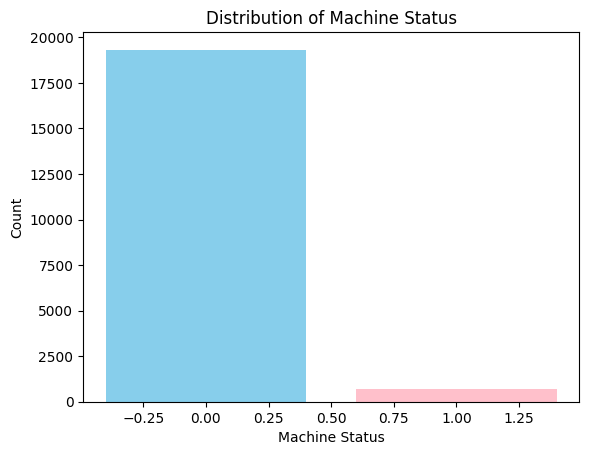

In [4]:
# 2. Exploratory Data Analysis (EDA)
# ===============================
# Analyze the target variable 'Machine Status'
print(df['Machine Status'].value_counts())   # Count occurrences of each class

# Visualize the distribution of the target variable
plt.bar(df['Machine Status'].value_counts().index, df['Machine Status'].value_counts(), color=['skyblue','pink'])
plt.title('Distribution of Machine Status')  # Plot title
plt.xlabel('Machine Status')                 # Label for x-axis
plt.ylabel('Count')                          # Label for y-axis
plt.show()

### Insights
This shows a highly imbalanced dataset:
Working machines = 96.6%
Faulty machines = 3.4%

## Implication:
Class imbalance may cause models to predict only the majority class.
Later steps must consider:
- Using class weights
- Oversampling (e.g., SMOTE) or undersampling (resampling)
- Threshold adjustment
- Choosing metrics beyond accuracy (e.g., recall, F1 score)

<Figure size 600x400 with 0 Axes>

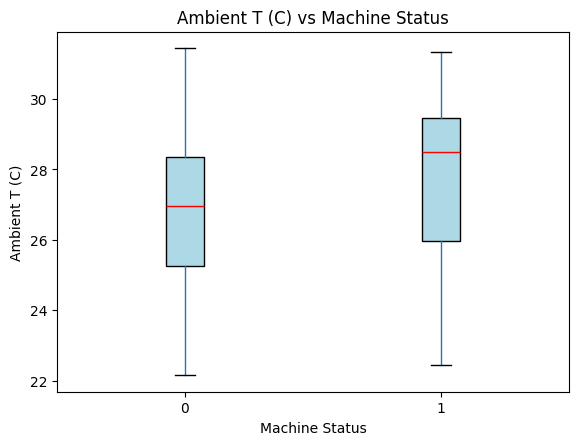

<Figure size 600x400 with 0 Axes>

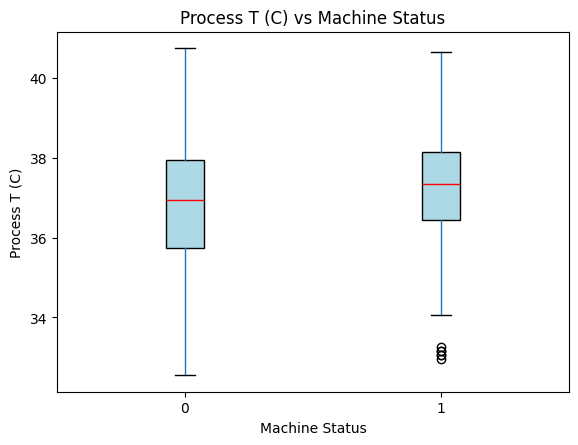

<Figure size 600x400 with 0 Axes>

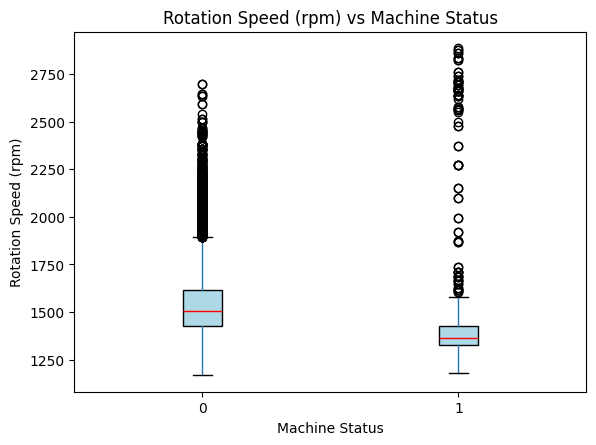

<Figure size 600x400 with 0 Axes>

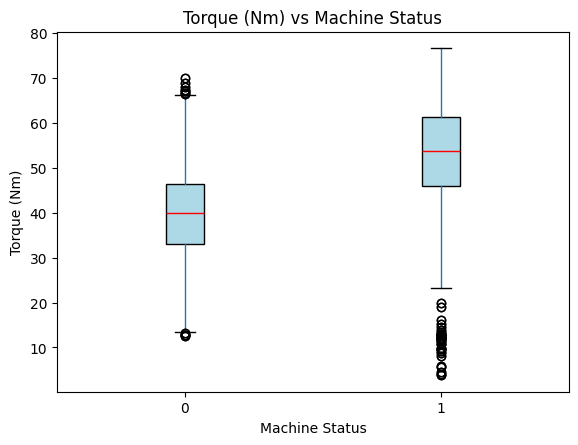

<Figure size 600x400 with 0 Axes>

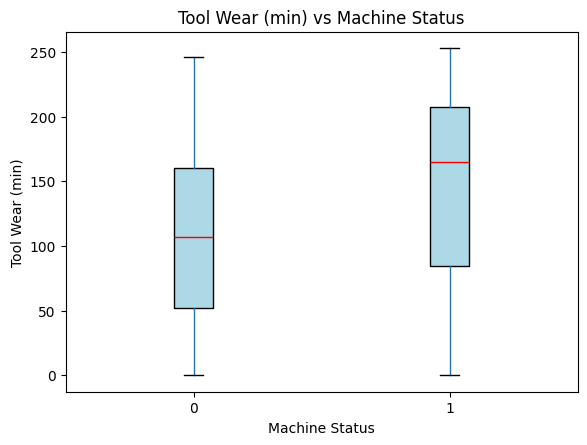

In [8]:
# Inspect numerical features
numerical_features = ['Ambient T (C)', 'Process T (C)', 'Rotation Speed (rpm)', 'Torque (Nm)', 'Tool Wear (min)']

# Visualize numerical features related to the target variable
for feature in numerical_features:
    plt.figure(figsize=(6,4))
    
    # Plot boxplot of feature grouped by Machine Status
    df.boxplot(column=feature, by='Machine Status', grid=False, patch_artist=True, boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'))
    plt.title(f'{feature} vs Machine Status')
    plt.suptitle('') # Remove default subtitle from pandas
    plt.xlabel('Machine Status')
    plt.ylabel(feature)
    plt.show()

### Insights

**1.Ambient Temperature (C)**
- Relatively stable with small variance.
Likely less direct impact on machine failure but could have a minor effect in combination with other features.
- Decision: Keep
- Rationale: **Low variance** but domain knowledge suggests environmental temperature may influence machine stress.

**2.Process Temperature (C)**
- Slightly higher than ambient temperature.
Machines operating near higher end may be at risk of overheating → potential predictor for failures.
Additionally, some failures occur at unusually low temperatures, which represent outliers and may indicate abnormal operating conditions or sensor errors.
- Decision: Keep
- Rationale: Directly linked to machine operation; **Low variance** but extreme values could indicate malfunction.

**3.Rotation Speed (rpm)**
- Varies significantly; some machines run almost twice as fast as others.
Extreme speeds may indicate operational anomalies → strong candidate predictor.
- Decision: Keep
- Rationale: **High variance**, likely correlated with machine stress/failure.

**4.Torque (Nm)**
- Distribution shows a wide range, suggesting some machines may experience high resistance.
High or low torque can directly contribute to mechanical issues → important predictor.
- Decision: Keep
- Rationale: **High variance**, direct mechanical measure, high relevance to predicting machine status.

**5.Tool Wear (min)**
- Shows significant variability, some tools almost brand new, some heavily used.
Higher tool wear logically increases the risk of machine failure → very important predictor.
- Decision: Keep
- Rationale: **High variance**, strong domain relevance, predictive of machine failure.

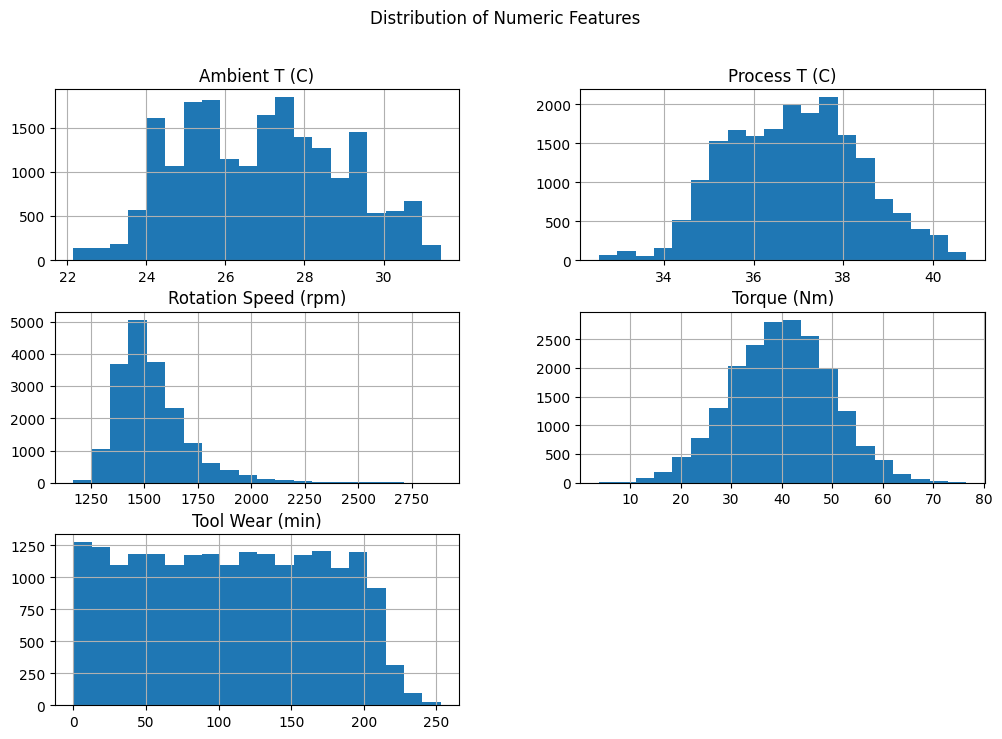

In [10]:
# Histogram for numeric features
numeric_features = ['Ambient T (C)', 'Process T (C)', 'Rotation Speed (rpm)', 'Torque (Nm)', 'Tool Wear (min)']
df[numeric_features].hist(bins=20, figsize=(12,8))
plt.suptitle('Distribution of Numeric Features')
plt.show()

**Ambient T (C)**  
- Distribution is roughly **multimodal**, indicating measurements were taken under different conditions or times.  
- Direct effect on Machine Status may be limited, but could reflect operational environment indirectly.

**Process T (C)**  
- Distribution is roughly **bell-shaped (normal)**, centered around 36–37°C.  
- High-temperature outliers may be associated with machine faults.

**Rotation Speed (rpm)**  
- Distribution is **right-skewed**, most values between 1400–1600 rpm, with a few extreme high values.  
- Extreme values may indicate abnormal machine behavior or recording errors; consider during data cleaning.

**Torque (Nm)**  
- Distribution is roughly **normal**, centered around 40–50 Nm.  
- High torque may indicate mechanical resistance or wear, directly related to potential faults.

**Tool Wear (min)**  
- Distribution is roughly **uniform**, ranging from 0–220 min.  
- Higher wear likely increases risk of machine failure; can be used directly as an important feature.

**Summary:**  
Histograms reveal numeric feature distributions, highlight outliers, and indicate potential multi-modal patterns.  
- Outliers observed in Rotation Speed may indicate anomalies or data entry errors.

Quality
L    11390
M     5696
H     1923
Name: count, dtype: int64


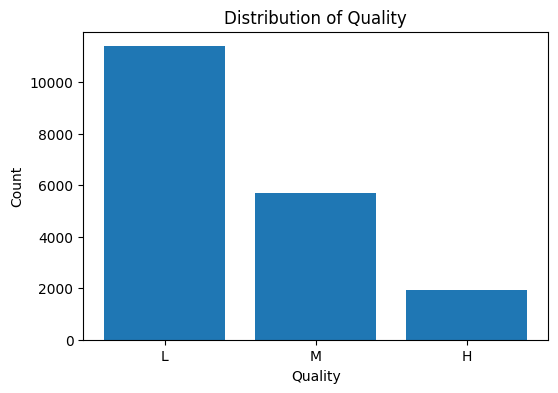

In [11]:
# Inspect the categorical feature 'Quality'
categorical_feature = 'Quality'

print(df[categorical_feature].value_counts())  # Count of each category

plt.figure(figsize=(6,4))
counts = df[categorical_feature].value_counts()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel(categorical_feature)
plt.ylabel('Count')
plt.title(f'Distribution of {categorical_feature}')
plt.show()

### Observation
Quality L is the most common, followed by M, while H is the least frequent. This means the dataset is slightly imbalanced across quality groups.
(Here, L = Low quality, M = Medium quality, and H = High quality.)

In [12]:
# Fix data types

# Product ID is categorical
df['Product ID'] = df['Product ID'].astype("category")

# Quality is categorical
df['Quality'] = df['Quality'].astype('category')

In [13]:
# Check the cleaned dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Unique ID             20000 non-null  int64   
 1   Product ID            20000 non-null  category
 2   Quality               19009 non-null  category
 3   Ambient T (C)         20000 non-null  float64 
 4   Process T (C)         19600 non-null  float64 
 5   Rotation Speed (rpm)  18812 non-null  float64 
 6   Torque (Nm)           20000 non-null  float64 
 7   Tool Wear (min)       20000 non-null  int64   
 8   Machine Status        20000 non-null  int64   
dtypes: category(2), float64(4), int64(3)
memory usage: 1.8 MB


In [14]:
# Check duplicates
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

0


### Data Cleaning
1. **Duplicates**  
   - Dropped duplicate rows (if any).  

2. **Data types**  
   - Converted categorical features to 'category'.

In [15]:
# 4. Prepare features
# ===============================
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [16]:
# Separate features and target
X = df.drop(['Machine Status', 'Unique ID', 'Product ID'], axis=1)  #drop target variable and meaningless variable
y = df['Machine Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

# Fill missing values (train only)
# Process T (C)
t_median = X_train['Process T (C)'].median()
X_train['Process T (C)'] = X_train['Process T (C)'].fillna(t_median)
X_test['Process T (C)'] = X_test['Process T (C)'].fillna(t_median)

# Rotation Speed (rpm)
rpm_median = X_train['Rotation Speed (rpm)'].median()
X_train['Rotation Speed (rpm)'] = X_train['Rotation Speed (rpm)'].fillna(rpm_median)
X_test['Rotation Speed (rpm)'] = X_test['Rotation Speed (rpm)'].fillna(rpm_median)

# Quality
quality_mode = X_train['Quality'].mode()[0]
X_train['Quality'] = X_train['Quality'].fillna(quality_mode)
X_test['Quality'] = X_test['Quality'].fillna(quality_mode)

print(X_train.isnull().sum())
print(X_test.isnull().sum())

# Feature Engineering: Add new informative features
def add_derived_features(df, eps=1e-6):
    df = df.copy()
    df['Torque_per_Speed'] = df['Torque (Nm)'] / (df['Rotation Speed (rpm)'] + eps)
    df['Temp_Diff'] = df['Process T (C)'] - df['Ambient T (C)']
    df['Torque_per_ToolWear'] = df['Torque (Nm)'] / (df['Tool Wear (min)'] + eps)
    return df

X_train = add_derived_features(X_train)
X_test  = add_derived_features(X_test)

# Identify categorical and numeric columns
categorical_cols = ['Quality']
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Quality                 0
Ambient T (C)           0
Process T (C)           0
Rotation Speed (rpm)    0
Torque (Nm)             0
Tool Wear (min)         0
dtype: int64
Quality                 0
Ambient T (C)           0
Process T (C)           0
Rotation Speed (rpm)    0
Torque (Nm)             0
Tool Wear (min)         0
dtype: int64
Categorical: ['Quality']
Numeric: ['Ambient T (C)', 'Process T (C)', 'Rotation Speed (rpm)', 'Torque (Nm)', 'Tool Wear (min)', 'Torque_per_Speed', 'Temp_Diff', 'Torque_per_ToolWear']


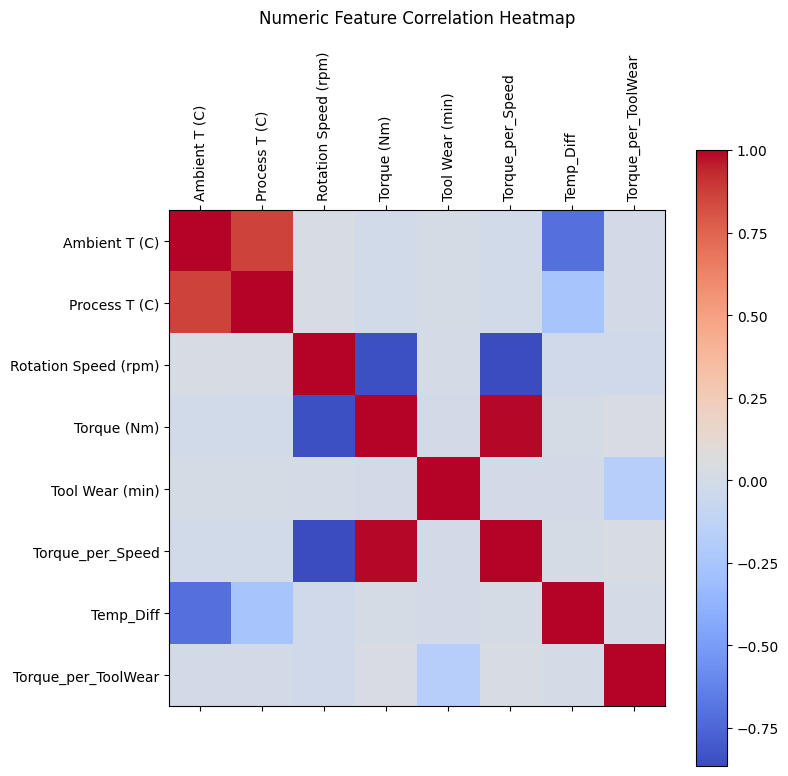

In [22]:
# 只计算 numeric features
corr_matrix = X_train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8,8))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

plt.title("Numeric Feature Correlation Heatmap", pad=20)
plt.show()

In [23]:
# Logistic Regression: drop Torque (Nm)
numeric_cols_lr = [col for col in numeric_cols if col != 'Torque (Nm)']

# One-Hot Encoding for categorical features 
# OneHotEncoder turns categories into binary columns. Example: Quality → [Quality_H, Quality_L, Quality_M]

# Preprocessor for Logistic Regression
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols_lr)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

**Missing Value Handling**
- Process T (C) & Rotation Speed (rpm) → filled with median (robust to outliers)  
- Quality → filled with mode
- Reason:
1. Quality is a **categorical** variable, so mean/median cannot be applied.
2. Mode imputation preserves the existing distribution without creating artificial labels.
3. Only ~5% of the values are missing, so using the most common category (L) minimizes distortion to the dataset.

**Feature Engineering**
- To improve model learning, three new numeric features were created:
1. Torque_per_Speed = Torque ÷ Rotation Speed
2. Temp_Diff = Process Temperature − Ambient Temperature
3. Torque_per_ToolWear = Torque ÷ Tool Wear

These features help capture performance patterns that are not directly visible in the raw data. A small constant (eps) prevents division-by-zero.

**Correlation Insights (from heatmap)**

1. Torque (Nm) & Torque_per_Speed → very high correlation (~1).
2. Torque_per_ToolWear and Temp_Diff shows low correlation with other features → adds independent information.

##### Interpretation:

- For linear models (Logistic Regression), consider dropping a highly correlated original feature (Torque (Nm)) to reduce multicollinearity.
- For tree-based models (RandomForest, XGBoost), all features can be kept; models handle correlated features automatically.

**Categorical Encoding**  
- `Quality` is the only categorical feature used.  
- One-Hot Encoding is applied to convert categories into binary columns.  
- I use `drop='first'` to avoid multicollinearity.  
- Example: `Quality` → `[Quality_L, Quality_M, Quality_H]` becomes two columns instead of three.  

**Numeric Features**  
- All remaining numeric columns (`Ambient T (C)`, `Process T (C)`, `Rotation Speed (rpm)`, `Torque (Nm)`, `Tool Wear (min)`, `Torque_per_Speed`, `Temp_Diff`, `Torque_per_ToolWear`) are standardized using **StandardScaler** in the pipeline.  
- Scaling ensures consistent magnitude and improves performance for models such as Logistic Regression, KNN, SVM, and tree-based methods when combined with CV or tuning.

**Dropped Columns**  
- `Unique ID` and `Product ID` are removed because they are identifiers and provide no predictive value.

**Preprocessor setup:**  
- `ColumnTransformer` combines one-hot encoding for categorical variables and scaling for numeric variables  
- `handle_unknown='ignore'` ensures new/unseen categories do not break the pipeline

In [24]:
# 5. Choose algorithms
# ===============================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Logistic Regression (needs scaling)
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=3000, random_state=42))
])

# KNN (needs scaling)
pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# SVC (needs scaling)
pipeline_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

# Decision Tree (no scaling needed)
pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Random Forest (no scaling needed)
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

I selected a variety of classification algorithms to compare their performance on predicting machine status:

1. **Logistic Regression**  
   - Simple, interpretable linear model for binary classification.  
   - Provides baseline performance.  
   - Sensitive to feature scaling, so numeric features are standardized.

2. **K-Nearest Neighbors (KNN)**  
   - Non-parametric model capturing local patterns in the data.  
   - Sensitive to scale, so numeric features are standardized.  
   - Useful for identifying clusters or similar operating conditions.

3. **Support Vector Classifier (SVC)**  
   - Effective in high-dimensional spaces.  
   - Handles non-linear boundaries using kernel trick.  
   - Requires feature scaling.

4. **Decision Tree**  
   - Non-linear model that can capture interactions between features.  
   - Robust to outliers and does **not** require feature scaling.  
   - Easy to interpret via tree visualization.

5. **Random Forest**  
   - Ensemble of decision trees, improves stability and reduces overfitting.  
   - Handles non-linear relationships and interactions well.  
   - Does **not** require feature scaling.

**Rationale:**  
By including linear, non-linear, and ensemble methods, I can compare simple vs complex models, understand which handles the data distribution better, and choose the best-performing algorithm for predicting machine faults.

### Build Pipelines for Classification Algorithms

- **Purpose:** Create machine learning pipelines that combine preprocessing and model fitting in one step. This ensures consistent handling of categorical encoding and numeric scaling for all models.

- **Pipelines:**
  - **Logistic Regression**  
    - Requires scaled features 
    - Good baseline for binary classification
  - **K-Nearest Neighbors (KNN)**  
    - Requires scaled features 
    - Simple non-parametric model capturing local patterns
  - **Support Vector Classifier (SVC)**  
    - Requires scaled features  
    - Effective for high-dimensional data and non-linear decision boundaries
  - **Decision Tree**  
    - Does **not** require scaling  
    - Handles non-linear relationships and interactions well
  - **Random Forest**  
    - Ensemble of decision trees, does **not** require scaling  
    - Reduces overfitting and improves generalization
- **Implementation:** Each pipeline combines the `preprocessor` (one-hot encoding + scaling) with the classifier, making it easy to train and evaluate multiple algorithms consistently.

In [25]:
# Dictionary of pipelines/models
pipelines = {
    'Logistic Regression': pipeline_lr,
    'KNN': pipeline_knn,
    'SVC': pipeline_svc,
    'Decision Tree': pipeline_dt,
    'Random Forest': pipeline_rf
}

# Train and evaluate
results = {}
for name, pipeline in pipelines.items():
    print(f"Training {name} ...")
    pipeline.fit(X_train, y_train) #Train on traning set
    y_pred = pipeline.predict(X_test) #Predict on testing set
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    }

# Show results as a DataFrame
pd.DataFrame(results).T

Training Logistic Regression ...
Training KNN ...
Training SVC ...
Training Decision Tree ...
Training Random Forest ...


,Accuracy,Precision,Recall,F1
Logistic Regression,0.97350,0.826087,0.279412,0.417582
KNN,0.97875,0.800000,0.500000,0.615385
SVC,0.97575,0.854545,0.345588,0.492147
Decision Tree,0.99200,0.888060,0.875000,0.881481
Random Forest,0.99350,0.991071,0.816176,0.895161


# Analysis:
- **Logistic Regression** -Good accuracy, but very low recall (0.28), meaning it often fails to detect faulty machines.
- **KNN** -Improves recall (0.50) and F1 compared to logistic regression, but performance is still moderate.  
- **SVC** -High precision (0.85) but low recall (0.35), indicating the model is cautious and misses many faults.
- **Decision Tree** -Strong balance with high recall (0.875) and strong F1 score (0.881).It captures most faulty machines while maintaining good precision.  
- **Random Forest** -Highest accuracy and precision, but slightly lower recall than Decision Tree, meaning it misses more faults.

**Conclusion:**  
- Since detecting faulty machines is the priority, recall is the key metric.
- Decision Tree is selected as the primary model, as it delivers the best recall while maintaining solid overall performance.
- Random Forest performs well but has lower recall, making it less suitable when missing faults carries higher cost.

In [26]:
# 6. Train and Test Decision Tree
# ===============================
from sklearn.metrics import confusion_matrix

# Fit Decision Tree pipeline
pipeline_dt.fit(X_train, y_train)

# Predict on test set
y_pred = pipeline_dt.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.992
Precision: 0.8880597014925373
Recall: 0.875
F1 Score: 0.8814814814814815
Confusion Matrix:
 [[3849   15]
 [  17  119]]


# Procedure:
- The dataset was split into `80% training and 20% testing`, using `stratify=y` and `random_state=42` to ensure consistent class distribution.
- Fit the Decision Tree pipeline (including preprocessing and scaling/encoding) was trained on the training data.
- Predict the machine status on the test set.
- Evaluate performance using `Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.`

**Analysis:**
- **High Recall (0.875)**: Most faulty machines are correctly identified, which is critical because missing a fault is costly.
- **Precision (0.888)**: Low false positives; a small number of working machines are incorrectly flagged.
- **F1 Score (0.881)**: Indicates a strong balance between precision and recall.
- **Accuracy (0.992)**: Overall, the model predicts correctly for nearly all cases.
- The confusion matrix shows very low false negatives (15) and manageable false positives (17), demonstrating that the Decision Tree is a strong baseline model before hyperparameter tuning.

In [27]:
# 7. Tune
# ===============================
# Decision Tree + Pipeline + Optuna (Recall Optimization)
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

# Use StratifiedKFold with fixed random_state for reproducibility
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    max_depth = trial.suggest_int("max_depth", 1, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 50)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    max_features = trial.suggest_categorical("max_features", [None, 'sqrt', 'log2'])
    
    # Build pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Use your preprocessor from feature prep
        ('classifier', DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            criterion=criterion,
            random_state=42,
        ))
    ])
    
    # Cross-validation on training set (5-fold) using Recall as metric
    recall = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall').mean()
    return recall  # maximize recall

# Create study
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100)  # can increase n_trials if needed

# Show best hyperparameters
print("Best hyperparameters:", study.best_params)
print("Best CV Recall:", study.best_value)

# Train final model with best hyperparameters
best_params = study.best_params
pipeline_dt_opt = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        criterion=best_params['criterion'],
        random_state=42
    ))
])

pipeline_dt_opt.fit(X_train, y_train)
y_pred = pipeline_dt_opt.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test F1 Score:", f1)
print("Confusion Matrix:\n", cm)

C:\Users\User\anaconda3\envs\AIML2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-19 15:14:54,883] A new study created in memory with name: no-name-0467659e-98c1-4912-a365-b08a2eef0bb9
[I 2026-03-19 15:14:55,449] Trial 0 finished with value: 0.6937648657832144 and parameters: {'max_depth': 12, 'min_samples_split': 48, 'min_samples_leaf': 15, 'criterion': 'gini', 'max_features': 'log2'}. Best is trial 0 with value: 0.6937648657832144.
[I 2026-03-19 15:14:56,048] Trial 1 finished with value: 0.7048250084947333 and parameters: {'max_depth': 19, 'min_samples_split': 36, 'min_samples_leaf': 1, 'criterion': 'gini', 'max_features': None}. Best is trial 1 with value: 0.7048250084947333.
[I 2026-03-19 15:14:56,550] Trial 2 finished with value: 0.6808698606863743 and parameters: {'max_depth': 10, 'min_samples_sp

Best hyperparameters: {'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy', 'max_features': 'sqrt'}
Best CV Recall: 0.8432381923207611
Test Accuracy: 0.9935
Test Precision: 0.9230769230769231
Test Recall: 0.8823529411764706
Test F1 Score: 0.9022556390977443
Confusion Matrix:
 [[3854   10]
 [  16  120]]


**Procedure:**
- Optuna was used to tune Decision Tree hyperparameters with Recall as the optimization target.
- Search space:
  - `max_depth`: 1–30
  - `min_samples_split`: 2–50
  - `min_samples_leaf`: 1–20
  - `criterion`: `'gini'` or `'entropy'`
- A pipeline was built combining preprocessing (encoding + scaling) and the Decision Tree classifier.

**Analysis:**
- Recall slightly increased from 0.875 → 0.882, meaning the tuned model catches more faults.
- Precision increased noticeably (0.888 → 0.923), resulting in fewer healthy machines being falsely flagged.
- F1 Score increased (0.881 → 0.902), showing a better balance between Precision and Recall.
- The confusion matrix shows fewer false positives and false negatives, reflecting the model is more mature.

**Conclusion:**
- Hyperparameter tuning with Optuna produced a more balanced and higher-performing Decision Tree model, with excellent overall performance while still prioritizing fault detection.

In [28]:
# 8. Check feature importance
# ===============================
# Get feature names after preprocessing
ohe_features = pipeline_dt_opt.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_features = np.concatenate([ohe_features, numeric_cols])

# Feature importances from trained Decision Tree
importances = pipeline_dt_opt.named_steps['classifier'].feature_importances_

# Create a DataFrame for better visualization
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp.sort_values(by='Importance', ascending=False, inplace=True)
print(feat_imp.head(10))

                Feature  Importance
5           Torque (Nm)    0.199207
7      Torque_per_Speed    0.193292
6       Tool Wear (min)    0.180993
4  Rotation Speed (rpm)    0.177097
8             Temp_Diff    0.166261
3         Process T (C)    0.028760
2         Ambient T (C)    0.017389
0             Quality_L    0.017199
9   Torque_per_ToolWear    0.016432
1             Quality_M    0.003370


# Analysis:
- **Torque (Nm)**: The most important feature. Large torque indicates higher mechanical resistance, a strong signal of potential machine issues.
- **Temp_Diff**: Difference between ambient and process temperature. Big temperature gaps may reflect abnormal heat buildup and operating stress.
- **Tool Wear (min)**: More usage increases the chance of faults, matching real mechanical behavior.
- **Rotation Speed (rpm)**: Irregular speeds can reflect stress or instability.
- **Ambient T (C) & Process T (C)**: Temperature features are moderately important, showing that environmental and internal machine temperature still matter but are less dominant compared to torque and wear.
- **Torque_per_Speed & Torque_per_ToolWear**: Contribute meaningful but smaller predictive power, showing that derived operational ratios also help the model detect abnormal behavior.
- **Quality (L, M):** Although Quality is correlated with machine status, its individual importance is low. This is because the Decision Tree prioritizes numeric features with higher information gain, and one-hot encoding splits Quality into separate columns, diluting its contribution.

**Conclusion:**  
The model primarily learns from mechanical and operational behavior. This aligns well with real machine physics and suggests the model is detecting meaningful operational patterns rather than relying on categorical labels.

In [29]:
# 9. Improve
# ===============================
#Improve: Feature Engineering + Decision Tree + Optuna

# Separate features and target
X = df.drop(['Machine Status', 'Unique ID', 'Product ID'], axis=1).copy()
y = df['Machine Status']

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fill missing values (train only)
# Process T (C)
t_median = X_train['Process T (C)'].median()
X_train['Process T (C)'] = X_train['Process T (C)'].fillna(t_median)
X_test['Process T (C)'] = X_test['Process T (C)'].fillna(t_median)

# Rotation Speed (rpm)
rpm_median = X_train['Rotation Speed (rpm)'].median()
X_train['Rotation Speed (rpm)'] = X_train['Rotation Speed (rpm)'].fillna(rpm_median)
X_test['Rotation Speed (rpm)'] = X_test['Rotation Speed (rpm)'].fillna(rpm_median)

# Quality
quality_mode = X_train['Quality'].mode()[0]
X_train['Quality'] = X_train['Quality'].fillna(quality_mode)
X_test['Quality'] = X_test['Quality'].fillna(quality_mode)

# Feature Engineering: 6 new features
eps = 1e-6  # prevent division by zero

def add_features_full(df):
    df = df.copy()
    df['Torque_per_Speed'] = df['Torque (Nm)'] / (df['Rotation Speed (rpm)'] + eps)
    df['Temp_Diff'] = df['Process T (C)'] - df['Ambient T (C)']
    df['Torque_per_ToolWear'] = df['Torque (Nm)'] / (df['Tool Wear (min)'] + eps)
    df['Torque_x_Rotation'] = df['Torque (Nm)'] * df['Rotation Speed (rpm)']
    df['Wear_x_Torque'] = df['Tool Wear (min)'] * df['Torque (Nm)']
    df['Temp_Ratio'] = df['Process T (C)'] / (df['Ambient T (C)'] + eps)
    return df

X_train = add_features_full(X_train)
X_test = add_features_full(X_test)

# Identify categorical and numeric columns
categorical_cols = ['Quality']
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Optuna tuning: Decision Tree
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 50)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    max_features = trial.suggest_categorical("max_features", [None, 'sqrt', 'log2'])

    # build pipeline with these params
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            criterion=criterion,
            max_features=max_features,
            random_state=42
        ))
    ])

    # cross-validate
    recall = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall', n_jobs=1)
    return recall.mean()

# create study with fixed sampler seed for reproducibility
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100)

print("Best params:", study.best_params)
print("Best CV mean Recall:", study.best_value)

# Refit pipeline with best params and evaluate on test set
best = study.best_params
pipeline_dt_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=best['max_depth'],
        min_samples_split=best['min_samples_split'],
        min_samples_leaf=best['min_samples_leaf'],
        criterion=best['criterion'],
        max_features=best.get('max_features', None),
        random_state=42
    ))
])

pipeline_dt_tuned.fit(X_train, y_train)
y_pred_tuned = pipeline_dt_tuned.predict(X_test)

print("\n=== Tuned Decision Tree (6 features) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.5f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.5f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.5f}")
print(f"F1 Score: {f1_score(y_test, y_pred_tuned):.5f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))

[I 2026-03-19 15:16:37,351] A new study created in memory with name: no-name-0f58f369-4973-45b6-8566-ce9e1960e257
[I 2026-03-19 15:16:37,719] Trial 0 finished with value: 0.7621134896364256 and parameters: {'max_depth': 12, 'min_samples_split': 48, 'min_samples_leaf': 15, 'criterion': 'gini', 'max_features': 'log2'}. Best is trial 0 with value: 0.7621134896364256.
[I 2026-03-19 15:16:38,638] Trial 1 finished with value: 0.7823819232076114 and parameters: {'max_depth': 19, 'min_samples_split': 36, 'min_samples_leaf': 1, 'criterion': 'gini', 'max_features': None}. Best is trial 1 with value: 0.7823819232076114.
[I 2026-03-19 15:16:38,945] Trial 2 finished with value: 0.7418790349983011 and parameters: {'max_depth': 10, 'min_samples_split': 27, 'min_samples_leaf': 9, 'criterion': 'entropy', 'max_features': 'log2'}. Best is trial 1 with value: 0.7823819232076114.
[I 2026-03-19 15:16:39,246] Trial 3 finished with value: 0.7491675161399932 and parameters: {'max_depth': 14, 'min_samples_split

Best params: {'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'gini', 'max_features': None}
Best CV mean Recall: 0.8800883452259599

=== Tuned Decision Tree (6 features) ===
Accuracy: 0.99550
Precision: 0.94697
Recall: 0.91912
F1 Score: 0.93284
Confusion Matrix:
 [[3857    7]
 [  11  125]]


**Objective:** Improve the Decision Tree model by adding informative features and tuning hyperparameters with Recall as the optimization metric to better detect faulty machines.

#### Feature Engineering

- Added more three new numeric features:
  1. **Torque_x_Rotation** = Torque × Rotation Speed → interaction feature to capture combined effect.
  2. **Wear_x_Torque** = Tool Wear × Torque → another interaction feature.
  3. **Temp_Ratio** = Process Temp ÷ Ambient Temp → identifies relative heating patterns.

These engineered features are simple, domain-relevant, and help the model better distinguish between normal and faulty machines.

#### Pipeline and Preprocessing
- **Categorical features:** `Quality` → One-Hot Encoding (drop first to avoid dummy trap).  
- **Numeric features:** StandardScaler to normalize all numeric variables.  
- **Pipeline:** Preprocessor + Decision Tree classifier.  

This ensures consistent preprocessing during cross-validation and hyperparameter tuning.

#### Optuna Hyperparameter Tuning

- **Hyperparameters searched:**
  - `max_depth`: 1–30  
  - `min_samples_split`: 2–50  
  - `min_samples_leaf`: 1–20  
  - `criterion`: "gini" or "entropy"  
  - `max_features`: None, "sqrt", "log2"  
- **Cross-validation:** 5-fold Stratified CV  
- **Optimization metric:** Recall  

The tuning aims to maximize Recall on the training set to reduce false negatives (faulty machines predicted as working).

#### Compare the performance between baseline and tuned

| Metric    | Baseline | Tuned |
|----------|----------|-------|
| Accuracy | 0.992   | 0.996 |
| Precision | 0.888  | 0.947 |
| Recall   | 0.875   | 0.919 |
| F1 Score | 0.881   | 0.933 |

### Conclusion
- Feature engineering combined with Optuna tuning improved model performance.
- The tuned Decision Tree is highly effective for detecting faulty machines while maintaining precision.